# titanic survival prediction — trial and error

proyek ini adalah eksplorasi end-to-end untuk memprediksi keselamatan penumpang titanic.
alur kerja mencakup pengambilan data langsung dari github, eksplorasi data, pembersihan data, rekayasa fitur, pelatihan model, evaluasi, serta pembuatan file submission baru.

## 1. impor library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('semua library berhasil diimpor')

semua library berhasil diimpor


## 2. pengambilan data dari github

In [2]:
base_url = 'https://raw.githubusercontent.com/aulyashabrina666-boop/partisipatif_ml_ds_1/f515da2c4798e507003f96c121e384eebb593860/data'

train_url      = f'{base_url}/train.csv'
test_url       = f'{base_url}/test.csv'
submission_url = f'{base_url}/gender_submission.csv'

df_train      = pd.read_csv(train_url)
df_test       = pd.read_csv(test_url)
df_submission = pd.read_csv(submission_url)

print(f'train      : {df_train.shape[0]} baris, {df_train.shape[1]} kolom')
print(f'test       : {df_test.shape[0]} baris, {df_test.shape[1]} kolom')
print(f'submission : {df_submission.shape[0]} baris, {df_submission.shape[1]} kolom')

train      : 891 baris, 12 kolom
test       : 418 baris, 11 kolom
submission : 418 baris, 2 kolom


## 3. eksplorasi data awal

In [3]:
print('lima baris pertama data training')
df_train.head()

lima baris pertama data training


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('info tipe data dan nilai non-null pada data training')
df_train.info()

info tipe data dan nilai non-null pada data training
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print('statistik deskriptif data training')
df_train.describe(include='all')

statistik deskriptif data training


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
print('jumlah nilai kosong per kolom pada data training')
missing_train = df_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train)

print('\njumlah nilai kosong per kolom pada data test')
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test)

jumlah nilai kosong per kolom pada data training
Cabin       687
Age         177
Embarked      2
dtype: int64

jumlah nilai kosong per kolom pada data test
Cabin    327
Age       86
Fare       1
dtype: int64


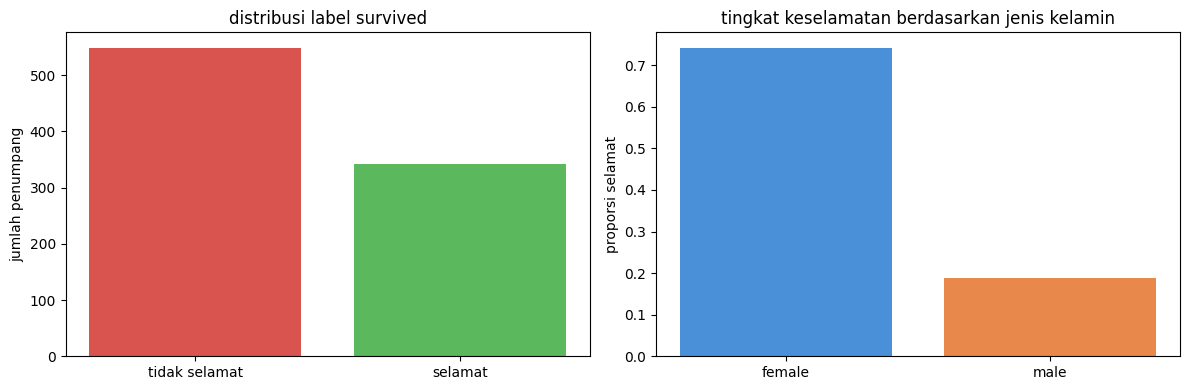

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survived_counts = df_train['Survived'].value_counts()
axes[0].bar(['tidak selamat', 'selamat'], survived_counts.values, color=['#d9534f', '#5cb85c'])
axes[0].set_title('distribusi label survived')
axes[0].set_ylabel('jumlah penumpang')

survived_by_sex = df_train.groupby('Sex')['Survived'].mean()
axes[1].bar(survived_by_sex.index, survived_by_sex.values, color=['#4a90d9', '#e8884a'])
axes[1].set_title('tingkat keselamatan berdasarkan jenis kelamin')
axes[1].set_ylabel('proporsi selamat')

plt.tight_layout()
plt.show()

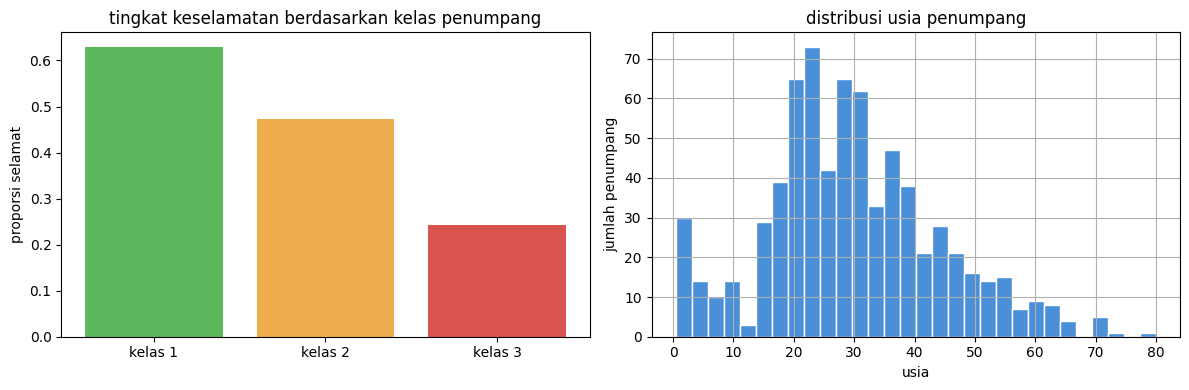

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survived_by_pclass = df_train.groupby('Pclass')['Survived'].mean()
axes[0].bar([f'kelas {i}' for i in survived_by_pclass.index], survived_by_pclass.values, color=['#5cb85c', '#f0ad4e', '#d9534f'])
axes[0].set_title('tingkat keselamatan berdasarkan kelas penumpang')
axes[0].set_ylabel('proporsi selamat')

df_train['Age'].dropna().hist(bins=30, ax=axes[1], color='#4a90d9', edgecolor='white')
axes[1].set_title('distribusi usia penumpang')
axes[1].set_xlabel('usia')
axes[1].set_ylabel('jumlah penumpang')

plt.tight_layout()
plt.show()

## 4. pembersihan dan rekayasa fitur

In [9]:
def ekstrak_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    rare = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    if title in rare:
        return 'rare'
    elif title == 'Mlle':
        return 'Miss'
    elif title == 'Ms':
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    return title

def bersihkan_data(df, is_train=True):
    df = df.copy()

    # ekstrak title dari nama
    df['Title'] = df['Name'].apply(ekstrak_title)

    # isi nilai kosong age menggunakan median per title
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

    # isi nilai kosong fare menggunakan median per pclass
    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

    # isi embarked dengan modus
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # fitur baru: ukuran keluarga
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # fitur baru: apakah sendirian
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # fitur baru: kelompok usia
    df['AgeGroup'] = pd.cut(df['Age'],
                             bins=[0, 12, 18, 35, 60, 100],
                             labels=['anak', 'remaja', 'dewasa_muda', 'dewasa', 'lansia'])

    # fitur baru: kelompok tarif
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['rendah', 'sedang', 'tinggi', 'sangat_tinggi'])

    # encoding variabel kategori
    le = LabelEncoder()
    for col in ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareBand']:
        df[col] = le.fit_transform(df[col].astype(str))

    # kolom yang dipakai sebagai fitur
    fitur = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
             'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']

    return df, fitur

df_train_clean, fitur = bersihkan_data(df_train, is_train=True)
df_test_clean, _ = bersihkan_data(df_test, is_train=False)

print('data training setelah pembersihan')
print(f'jumlah nilai kosong yang tersisa: {df_train_clean[fitur].isnull().sum().sum()}')
print(f'fitur yang digunakan: {fitur}')

data training setelah pembersihan
jumlah nilai kosong yang tersisa: 0
fitur yang digunakan: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']


## 5. pelatihan dan evaluasi model

In [10]:
x = df_train_clean[fitur]
y = df_train_clean['Survived']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kandidat_model = {
    'logistic regression': LogisticRegression(max_iter=1000, random_state=42),
    'random forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'gradient boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
}

hasil_cv = {}
for nama, model in kandidat_model.items():
    skor = cross_val_score(model, x, y, cv=cv, scoring='accuracy')
    hasil_cv[nama] = skor
    print(f'{nama} >> rata-rata akurasi: {skor.mean():.4f} ( std: {skor.std():.4f} )')

print('\nmodel terbaik berdasarkan cross-validation:')
model_terbaik_nama = max(hasil_cv, key=lambda k: hasil_cv[k].mean())
print(f'{model_terbaik_nama} dengan akurasi rata-rata {hasil_cv[model_terbaik_nama].mean():.4f}')

logistic regression >> rata-rata akurasi: 0.8059 ( std: 0.0167 )
random forest >> rata-rata akurasi: 0.8372 ( std: 0.0144 )
gradient boosting >> rata-rata akurasi: 0.8395 ( std: 0.0104 )

model terbaik berdasarkan cross-validation:
gradient boosting dengan akurasi rata-rata 0.8395


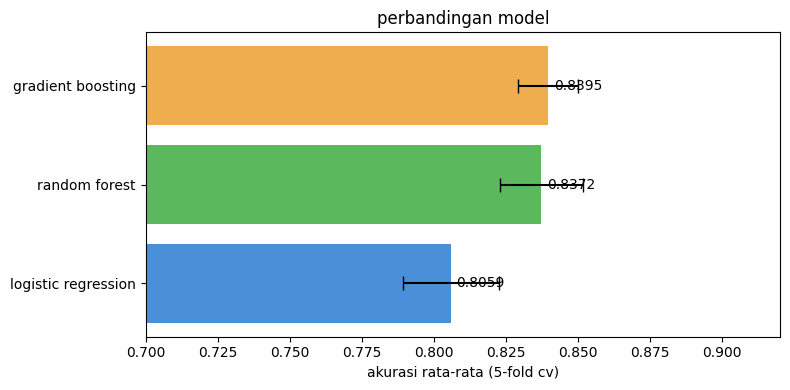

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(hasil_cv.keys())
means = [hasil_cv[k].mean() for k in names]
stds  = [hasil_cv[k].std() for k in names]

bars = ax.barh(names, means, xerr=stds, color=['#4a90d9', '#5cb85c', '#f0ad4e'], capsize=5)
ax.set_xlim(0.7, 0.92)
ax.set_xlabel('akurasi rata-rata (5-fold cv)')
ax.set_title('perbandingan model')
for bar, val in zip(bars, means):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

akurasi pada data training penuh: 0.9405

laporan klasifikasi pada data training:
               precision    recall  f1-score   support

tidak selamat       0.93      0.97      0.95       549
      selamat       0.96      0.89      0.92       342

     accuracy                           0.94       891
    macro avg       0.94      0.93      0.94       891
 weighted avg       0.94      0.94      0.94       891



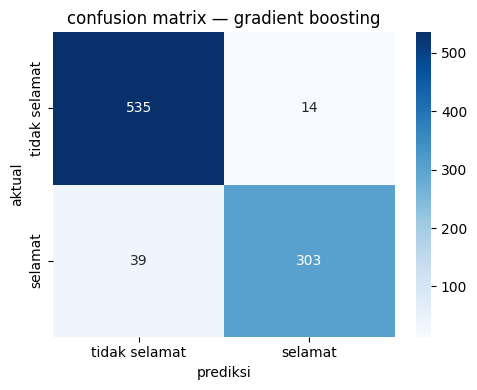

In [12]:
model_terbaik = kandidat_model[model_terbaik_nama]
model_terbaik.fit(x, y)

y_pred_train = model_terbaik.predict(x)
print(f'akurasi pada data training penuh: {accuracy_score(y, y_pred_train):.4f}')
print()
print('laporan klasifikasi pada data training:')
print(classification_report(y, y_pred_train, target_names=['tidak selamat', 'selamat']))

cm = confusion_matrix(y, y_pred_train)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['tidak selamat', 'selamat'],
            yticklabels=['tidak selamat', 'selamat'])
ax.set_xlabel('prediksi')
ax.set_ylabel('aktual')
ax.set_title(f'confusion matrix — {model_terbaik_nama}')
plt.tight_layout()
plt.show()

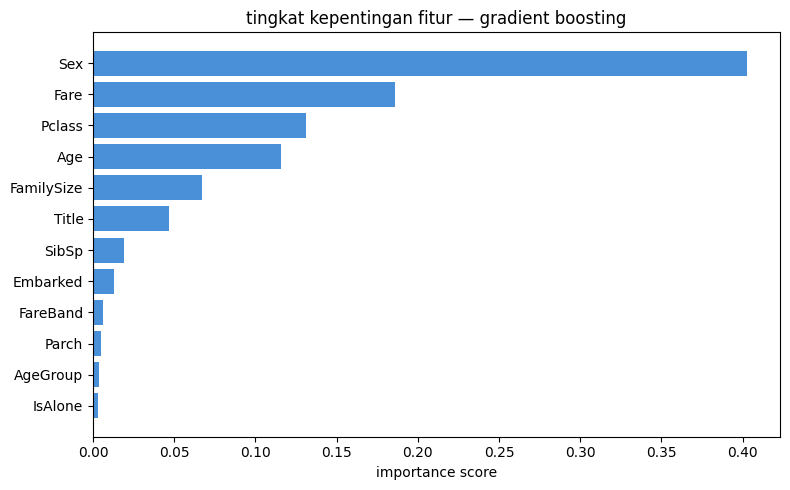

In [13]:
if hasattr(model_terbaik, 'feature_importances_'):
    importances = model_terbaik.feature_importances_
    fi_df = pd.DataFrame({'fitur': fitur, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi_df['fitur'], fi_df['importance'], color='#4a90d9')
    ax.set_title(f'tingkat kepentingan fitur — {model_terbaik_nama}')
    ax.set_xlabel('importance score')
    plt.tight_layout()
    plt.show()
else:
    print('model yang dipilih tidak memiliki feature_importances_')

## 6. prediksi data test dan pembuatan file submission baru

In [14]:
x_test = df_test_clean[fitur]
prediksi_test = model_terbaik.predict(x_test)

submission_baru = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': prediksi_test
})

output_path = 'data/gender_submission.csv'
submission_baru.to_csv(output_path, index=False)

print(f'file submission berhasil disimpan ke: {output_path}')
print(f'jumlah prediksi: {len(submission_baru)}')
print(f'prediksi selamat: {prediksi_test.sum()} penumpang')
print(f'prediksi tidak selamat: {(prediksi_test == 0).sum()} penumpang')
submission_baru.head(10)

file submission berhasil disimpan ke: data/gender_submission.csv
jumlah prediksi: 418
prediksi selamat: 151 penumpang
prediksi tidak selamat: 267 penumpang


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


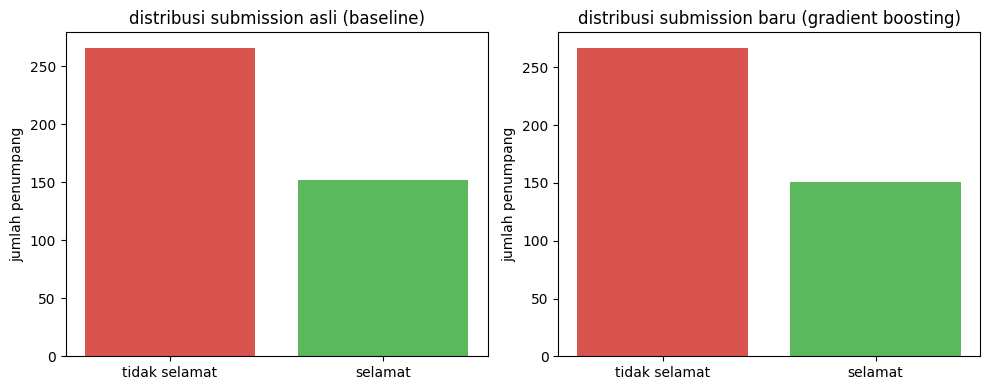


perbandingan distribusi prediksi:
submission asli  — selamat: 152, tidak selamat: 266
submission baru  — selamat: 151, tidak selamat: 267


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

original_survived = df_submission['Survived'].value_counts()
axes[0].bar(['tidak selamat', 'selamat'],
            [original_survived.get(0, 0), original_survived.get(1, 0)],
            color=['#d9534f', '#5cb85c'])
axes[0].set_title('distribusi submission asli (baseline)')
axes[0].set_ylabel('jumlah penumpang')

new_survived = submission_baru['Survived'].value_counts()
axes[1].bar(['tidak selamat', 'selamat'],
            [new_survived.get(0, 0), new_survived.get(1, 0)],
            color=['#d9534f', '#5cb85c'])
axes[1].set_title(f'distribusi submission baru ({model_terbaik_nama})')
axes[1].set_ylabel('jumlah penumpang')

plt.tight_layout()
plt.show()

print('\nperbandingan distribusi prediksi:')
print(f'submission asli  — selamat: {original_survived.get(1,0)}, tidak selamat: {original_survived.get(0,0)}')
print(f'submission baru  — selamat: {new_survived.get(1,0)}, tidak selamat: {new_survived.get(0,0)}')

## 7. ringkasan hasil

proses eksplorasi dan pemodelan telah selesai. berikut rangkuman alur yang telah dikerjakan:

pengambilan data dilakukan langsung dari github menggunakan raw url tanpa menyimpan file terlebih dahulu.

eksplorasi data menunjukkan bahwa variabel sex, pclass, dan fare memiliki pengaruh paling kuat terhadap keselamatan penumpang. kolom cabin memiliki banyak nilai kosong sehingga tidak digunakan sebagai fitur langsung.

pembersihan data mencakup pengisian nilai kosong age menggunakan median per title, pengisian fare menggunakan median per pclass, dan pengisian embarked dengan modus.

rekayasa fitur menghasilkan kolom baru yaitu title, familysize, isalone, agegroup, dan fareband yang memperkaya representasi data.

tiga model dievaluasi menggunakan 5-fold stratified cross-validation. model terbaik dipilih secara otomatis berdasarkan akurasi rata-rata tertinggi.

output akhir berupa file gender_submission.csv yang baru tersimpan di folder data dan berisi prediksi keselamatan seluruh 418 penumpang pada data test.